# Phase 11: Best Model Diagnostic Notebook

This notebook evaluates existing PPO checkpoints (especially `best_model.zip`) on the simulator and produces:
- Terminal outcome distribution (`success`, `escalation`, `dropout`, `timeout`, `unresolved_close`)
- Action mix distribution
- Episode length and reward summary
- Close-action quality diagnostics (progress/turn at close)

It is read-only with respect to training; it only runs inference and analysis.

In [32]:
from pathlib import Path
from collections import Counter
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make repository imports work regardless of notebook launch directory
repo_root = Path.cwd()
if repo_root.name == "subnotebooks":
    repo_root = repo_root.parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    from stable_baselines3 import PPO
except Exception as exc:
    raise RuntimeError(
        "stable-baselines3 is not installed in the selected kernel. "
        "Run: pip install stable-baselines3\n"
    ) from exc

from Simulation_4.env.support_env import SupportEnv

plt.style.use("seaborn-v0_8-darkgrid")

In [33]:
# ---- Configuration ----
ROOT = repo_root / 'Simulation_4' / 'artifacts'
EPISODES = 400
SEED_BASE = 70000
NLG_ENABLED = False

MODEL_ORDER = [
    'baseline_beating_model.zip',
    'best_model.zip',
    'checkpoint_500k.zip',
    'final_model.zip',
]

candidate_dirs = [
    ROOT / 'phase10_prod/models',
    ROOT / 'phase10_final/models',
]
unique_dirs = []
for d in candidate_dirs:
    if d not in unique_dirs:
        unique_dirs.append(d)

available_models = []
for name in MODEL_ORDER:
    for d in unique_dirs:
        p = d / name
        if p.exists():
            available_models.append(p)
            break
if not available_models:
    raise FileNotFoundError(f'No checkpoint found in expected paths under {ROOT}')

available_models

[PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/baseline_beating_model.zip'),
 PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/best_model.zip'),
 PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_final/models/checkpoint_500k.zip'),
 PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/final_model.zip')]

In [34]:
def run_policy_diagnostics(model_path: Path, episodes: int = 400, seed_base: int = 70000, nlg_enabled: bool = False):
    model = PPO.load(str(model_path))
    env = SupportEnv(artifacts_root=str(ROOT), nlg_enabled=bool(nlg_enabled))

    terminal_types = Counter()
    action_counts = Counter()

    rows = []
    close_progress_values = []
    close_turn_values = []

    for ep in range(int(episodes)):
        obs, _ = env.reset(seed=int(seed_base + ep))
        done = False
        ep_reward = 0.0
        ep_turns = 0
        info = {}

        while not done:
            pre_progress = float(env.state.get('progress', 0.0))
            pre_turn = int(env.state.get('turn_count', 0))

            action, _ = model.predict(obs, deterministic=True)
            a = int(action)
            action_counts[a] += 1

            if a == 4:  # Close
                close_progress_values.append(pre_progress)
                close_turn_values.append(pre_turn)

            obs, reward, done, truncated, info = env.step(a)
            ep_reward += float(reward)
            ep_turns += 1
            if truncated:
                done = True

        terminal_type = str((info.get('last_transition_outcome', {}) or {}).get('terminal_type', 'unknown'))
        terminal_types[terminal_type] += 1

        rows.append({
            'episode': int(ep),
            'terminal_type': terminal_type,
            'turns': int(ep_turns),
            'episode_reward': float(ep_reward),
            'subflow': str(env.state.get('subflow', '')),
            'tier': str(env.state.get('tier', '')),
            'persona': str(env.state.get('persona_label', '')),
            'resolved': int(env.state.get('resolved', 0)),
            'escalated': int(env.state.get('escalated', 0)),
            'dropped_off': int(env.state.get('dropped_off', 0)),
        })

    env.close()

    df = pd.DataFrame(rows)

    action_names = {0: 'AskInfo', 1: 'ProvideSolution', 2: 'AffectiveRepair', 3: 'Escalate', 4: 'Close'}
    total_actions = max(sum(action_counts.values()), 1)
    action_mix = pd.DataFrame([
        {'action_id': a, 'action_name': action_names[a], 'count': int(action_counts[a]), 'rate': float(action_counts[a] / total_actions)}
        for a in range(5)
    ])

    terminal_summary = (
        df.groupby('terminal_type', as_index=False)
        .agg(count=('episode', 'size'), mean_turns=('turns', 'mean'), mean_reward=('episode_reward', 'mean'))
        .sort_values('count', ascending=False)
    )
    terminal_summary['rate'] = terminal_summary['count'] / max(len(df), 1)

    close_diag = {
        'close_count': int(len(close_progress_values)),
        'progress_mean': float(np.mean(close_progress_values)) if close_progress_values else np.nan,
        'progress_p25': float(np.percentile(close_progress_values, 25)) if close_progress_values else np.nan,
        'progress_p50': float(np.percentile(close_progress_values, 50)) if close_progress_values else np.nan,
        'turn_mean': float(np.mean(close_turn_values)) if close_turn_values else np.nan,
        'turn_p25': float(np.percentile(close_turn_values, 25)) if close_turn_values else np.nan,
        'turn_p50': float(np.percentile(close_turn_values, 50)) if close_turn_values else np.nan,
        'close_with_progress_lt_020': int(sum(1 for p in close_progress_values if p < 0.20)),
        'close_with_turn_lt_5': int(sum(1 for t in close_turn_values if t < 5)),
    }

    overall = {
        'episodes': int(len(df)),
        'mean_episode_turns': float(df['turns'].mean()),
        'mean_episode_reward': float(df['episode_reward'].mean()),
        'std_episode_reward': float(df['episode_reward'].std(ddof=0)),
        'model_path': str(model_path),
    }

    return {
        'episode_df': df,
        'terminal_summary': terminal_summary,
        'action_mix': action_mix,
        'close_diag': close_diag,
        'overall': overall,
    }

In [35]:
available_models

[PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/baseline_beating_model.zip'),
 PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/best_model.zip'),
 PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_final/models/checkpoint_500k.zip'),
 PosixPath('/Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/final_model.zip')]

In [36]:
# Select the first available model in the requested order
MODEL_PATH = available_models[2]
result = run_policy_diagnostics(MODEL_PATH, episodes=EPISODES, seed_base=SEED_BASE, nlg_enabled=NLG_ENABLED)

print('Overall:')
for k, v in result['overall'].items():
    print(f'  {k}: {v}')

print('\nClose diagnostic:')
for k, v in result['close_diag'].items():
    print(f'  {k}: {v}')

DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6354.45it/s]


Overall:
  episodes: 400
  mean_episode_turns: 7.3575
  mean_episode_reward: 0.7531220239354233
  std_episode_reward: 2.408090800087068
  model_path: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_final/models/checkpoint_500k.zip

Close diagnostic:
  close_count: 71
  progress_mean: 0.021592701648891363
  progress_p25: 0.0
  progress_p50: 0.017899793497792388
  turn_mean: 0.0
  turn_p25: 0.0
  turn_p50: 0.0
  close_with_progress_lt_020: 71
  close_with_turn_lt_5: 71


In [37]:
result['terminal_summary']

,terminal_type,count,mean_turns,mean_reward,rate
2,success,158,11.284810,3.307278,0.3950
1,escalation,100,1.340000,0.584155,0.2500
4,unresolved_close,71,1.000000,-1.157328,0.1775
0,dropout,58,11.982759,-2.701616,0.1450
3,timeout,13,20.000000,-3.142515,0.0325


In [38]:
result['action_mix']

,action_id,action_name,count,rate
0,0,AskInfo,2065,0.701665
1,1,ProvideSolution,651,0.221203
2,2,AffectiveRepair,56,0.019028
3,3,Escalate,100,0.033979
4,4,Close,71,0.024125


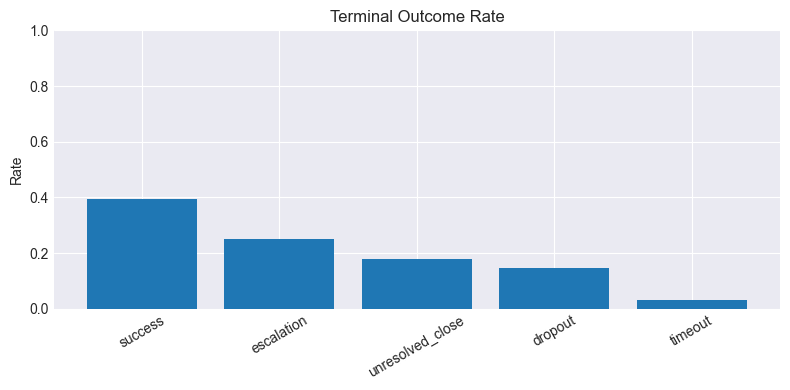

In [39]:
# Terminal outcome plot
ts = result['terminal_summary'].copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ts['terminal_type'], ts['rate'])
ax.set_title('Terminal Outcome Rate')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

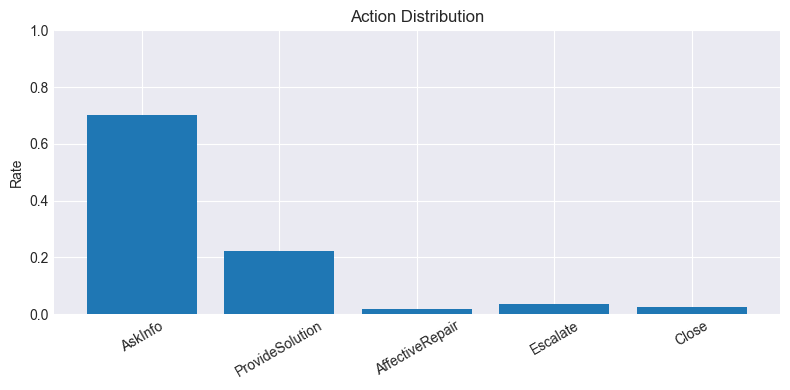

In [40]:
# Action mix plot
am = result['action_mix'].copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(am['action_name'], am['rate'])
ax.set_title('Action Distribution')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

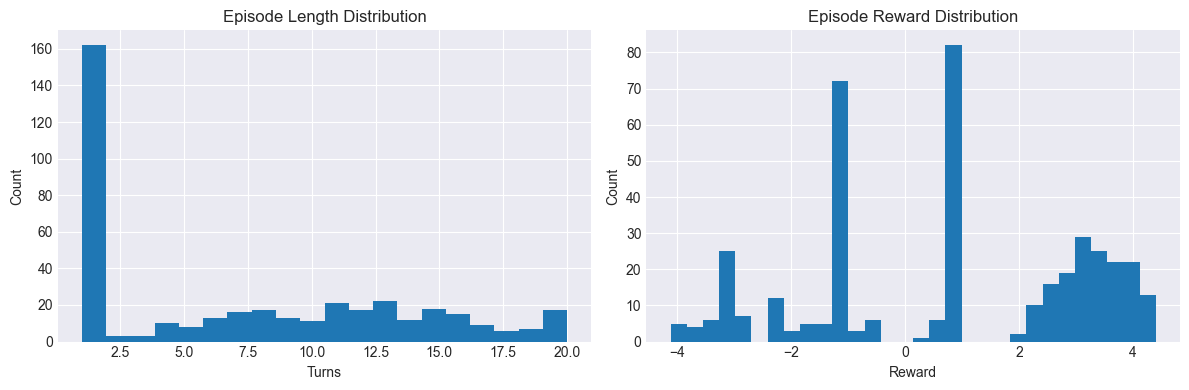

In [41]:
# Turn-length and reward distributions
df = result['episode_df']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['turns'], bins=20)
axes[0].set_title('Episode Length Distribution')
axes[0].set_xlabel('Turns')
axes[0].set_ylabel('Count')

axes[1].hist(df['episode_reward'], bins=30)
axes[1].set_title('Episode Reward Distribution')
axes[1].set_xlabel('Reward')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [42]:
# Ordered comparison across key checkpoints
MODEL_ORDER = [
    'baseline_beating_model.zip',
    'best_model.zip',
    'checkpoint_500k.zip',
    'final_model.zip',
]

# Prefer the currently selected model family first, then fall back to known model dirs
primary_models_dir = MODEL_PATH.parent
candidate_dirs = [primary_models_dir, ROOT / 'phase10_prod/models', ROOT / 'phase10_final/models']

# Deduplicate dirs while preserving order
unique_dirs = []
for d in candidate_dirs:
    if d not in unique_dirs:
        unique_dirs.append(d)

selection_rows = []
selected_paths = []
for name in MODEL_ORDER:
    found_path = None
    found_dir = None
    for d in unique_dirs:
        p = d / name
        if p.exists():
            found_path = p
            found_dir = d
            break
    selection_rows.append({
        'requested_model': name,
        'found': bool(found_path),
        'source_dir': str(found_dir) if found_dir else '',
        'path': str(found_path) if found_path else '',
    })
    if found_path is not None:
        selected_paths.append(found_path)

selection_df = pd.DataFrame(selection_rows)
print('Model availability (requested order):')
selection_df

if not selected_paths:
    raise FileNotFoundError('None of the requested checkpoints were found in candidate directories.')

comparison_rows = []
for rank, mp in enumerate(selected_paths, start=1):
    out = run_policy_diagnostics(mp, episodes=200, seed_base=SEED_BASE, nlg_enabled=False)
    ts = out['terminal_summary'].set_index('terminal_type')['rate'].to_dict()
    comparison_rows.append({
        'rank': rank,
        'model_name': mp.name,
        'model_path': str(mp),
        'mean_turns': out['overall']['mean_episode_turns'],
        'mean_reward': out['overall']['mean_episode_reward'],
        'success_rate': ts.get('success', 0.0),
        'escalation_rate': ts.get('escalation', 0.0),
        'dropout_rate': ts.get('dropout', 0.0),
        'timeout_rate': ts.get('timeout', 0.0),
        'unresolved_close_rate': ts.get('unresolved_close', 0.0),
    })

pd.DataFrame(comparison_rows)

Model availability (requested order):
DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6035.31it/s]


DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3829.67it/s]


DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6366.71it/s]


DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5926.03it/s]


,rank,model_name,model_path,mean_turns,mean_reward,success_rate,escalation_rate,dropout_rate,timeout_rate,unresolved_close_rate
0,1,baseline_beating_model.zip,/Users/tishabhavsar/RL_Project /AdaptiveBandit...,7.85,0.690514,0.395,0.250,0.180,0.025,0.15
1,2,best_model.zip,/Users/tishabhavsar/RL_Project /AdaptiveBandit...,10.68,1.220087,0.585,0.135,0.255,0.025,0.00
2,3,checkpoint_500k.zip,/Users/tishabhavsar/RL_Project /AdaptiveBandit...,7.46,0.747983,0.395,0.260,0.165,0.010,0.17
3,4,final_model.zip,/Users/tishabhavsar/RL_Project /AdaptiveBandit...,10.70,1.167631,0.580,0.130,0.265,0.025,0.00


## Deeper Analysis
Use these cells to quantify uncertainty and find weak segments (subflow/persona/tier) where failures concentrate.

In [43]:
# ====== What the current diagnostics tell us ======
print("=" * 70)
print("CURRENT MODEL OUTPUT INTERPRETATION")
print("=" * 70)

df_ep = result['episode_df']
overall = result['overall']

success_rate = (df_ep['terminal_type'] == 'success').sum() / len(df_ep)
escalation_rate = (df_ep['terminal_type'] == 'escalation').sum() / len(df_ep)
dropout_rate = (df_ep['terminal_type'] == 'dropout').sum() / len(df_ep)
unresolved_rate = (df_ep['terminal_type'] == 'unresolved_close').sum() / len(df_ep)

print(f"\n1. TERMINAL OUTCOMES (per {len(df_ep)} episodes):")
print(f"   Success:      {success_rate:6.1%}  → customer problem resolved")
print(f"   Escalation:   {escalation_rate:6.1%}  → model gave up early")
print(f"   Dropout:      {dropout_rate:6.1%}  → customer left")
print(f"   Unresolved Close: {unresolved_rate:6.1%}  → model said Close but env says unresolved")
print(f"   Timeout:      {(1 - success_rate - escalation_rate - dropout_rate - unresolved_rate):6.1%}  → max turns hit")

action_mix = result['action_mix']
print(f"\n2. ACTION MIX (policy behavior):")
for _, row in action_mix.iterrows():
    if row['count'] > 0:
        print(f"   {row['action_name']:<20} {row['rate']:6.1%}  ({row['count']:>4} actions)")

print(f"\n3. EPISODE DYNAMICS:")
print(f"   Mean episode length: {overall['mean_episode_turns']:.1f} turns")
print(f"   Mean reward:         {overall['mean_episode_reward']:+.3f}")
print(f"   Reward std dev:      {overall['std_episode_reward']:.3f}")

print(f"\n4. QUICK INTERPRETATION:")
if success_rate > 0.5:
    print(f"   ✓ Model succeeds majority of the time ({success_rate:.1%})")
else:
    print(f"   ✗ Model struggles to resolve (only {success_rate:.1%} success)")

if escalation_rate > dropout_rate and escalation_rate > 0.15:
    print(f"   ⚠ High escalation rate ({escalation_rate:.1%}) → policy may lack confidence")
    
if unresolved_rate > 0.1:
    print(f"   ⚠ Frequent unresolved closes ({unresolved_rate:.1%}) → Close timing/condition mismatch")

if overall['mean_episode_turns'] < 5:
    print(f"   ⚠ Very short episodes ({overall['mean_episode_turns']:.1f} turns) → possibly shortcutting")
elif overall['mean_episode_turns'] > 15:
    print(f"   ⚠ Very long episodes ({overall['mean_episode_turns']:.1f} turns) → inefficient action sequence")


CURRENT MODEL OUTPUT INTERPRETATION

1. TERMINAL OUTCOMES (per 400 episodes):
   Success:       39.5%  → customer problem resolved
   Escalation:    25.0%  → model gave up early
   Dropout:       14.5%  → customer left
   Unresolved Close:  17.8%  → model said Close but env says unresolved
   Timeout:        3.2%  → max turns hit

2. ACTION MIX (policy behavior):
   AskInfo               70.2%  (2065 actions)
   ProvideSolution       22.1%  ( 651 actions)
   AffectiveRepair        1.9%  (  56 actions)
   Escalate               3.4%  ( 100 actions)
   Close                  2.4%  (  71 actions)

3. EPISODE DYNAMICS:
   Mean episode length: 7.4 turns
   Mean reward:         +0.753
   Reward std dev:      2.408

4. QUICK INTERPRETATION:
   ✗ Model struggles to resolve (only 39.5% success)
   ⚠ High escalation rate (25.0%) → policy may lack confidence
   ⚠ Frequent unresolved closes (17.8%) → Close timing/condition mismatch


In [44]:
# ====== Success/Failure Rates by Segment ======
print("\n" + "=" * 70)
print("SEGMENT-LEVEL PERFORMANCE (Where is the model strong/weak?)")
print("=" * 70)

df_ep = result['episode_df']

# By SUBFLOW
print("\nSUCCESS RATE BY SUBFLOW:")
subflow_summary = df_ep.groupby('subflow').agg(
    count=('episode', 'size'),
    success_rate=('terminal_type', lambda x: (x == 'success').sum() / len(x)),
    mean_reward=('episode_reward', 'mean'),
    mean_turns=('turns', 'mean'),
).sort_values('success_rate', ascending=False)

for subflow, row in subflow_summary.iterrows():
    mark = '✓' if row['success_rate'] > 0.5 else '✗'
    print(f"  {mark} {subflow:<30} {row['success_rate']:6.1%}  (n={int(row['count']):>3}, reward={row['mean_reward']:+.2f}, turns={row['mean_turns']:>5.1f})")

# By PERSONA
print("\nSUCCESS RATE BY PERSONA:")
persona_summary = df_ep.groupby('persona').agg(
    count=('episode', 'size'),
    success_rate=('terminal_type', lambda x: (x == 'success').sum() / len(x)),
    escalation_rate=('terminal_type', lambda x: (x == 'escalation').sum() / len(x)),
    mean_turns=('turns', 'mean'),
).sort_values('success_rate', ascending=False)

for persona, row in persona_summary.iterrows():
    mark = '✓' if row['success_rate'] > 0.5 else '✗'
    print(f"  {mark} {persona:<20} success={row['success_rate']:6.1%}  escalate={row['escalation_rate']:6.1%}  (n={int(row['count']):>3}, turns={row['mean_turns']:>5.1f})")

# By TIER
print("\nSUCCESS RATE BY TIER:")
tier_summary = df_ep.groupby('tier').agg(
    count=('episode', 'size'),
    success_rate=('terminal_type', lambda x: (x == 'success').sum() / len(x)),
    dropout_rate=('terminal_type', lambda x: (x == 'dropout').sum() / len(x)),
    mean_turns=('turns', 'mean'),
).sort_values('success_rate', ascending=False)

for tier, row in tier_summary.iterrows():
    mark = '✓' if row['success_rate'] > 0.5 else '✗'
    print(f"  {mark} {tier:<20} success={row['success_rate']:6.1%}  dropout={row['dropout_rate']:6.1%}  (n={int(row['count']):>3}, turns={row['mean_turns']:>5.1f})")


SEGMENT-LEVEL PERFORMANCE (Where is the model strong/weak?)

SUCCESS RATE BY SUBFLOW:
  ✓ pricing_2                      100.0%  (n=  1, reward=+2.60, turns= 16.0)
  ✓ timing_2                       100.0%  (n=  3, reward=+3.45, turns= 10.3)
  ✓ status_service_added           100.0%  (n=  3, reward=+3.20, turns= 12.0)
  ✓ manage_pay_bill                100.0%  (n=  1, reward=+3.05, turns= 13.0)
  ✓ status_delivery_time           100.0%  (n=  2, reward=+3.05, turns= 13.0)
  ✓ shirt_other_4                  100.0%  (n=  4, reward=+3.58, turns=  9.5)
  ✓ jacket_other_2                 100.0%  (n=  2, reward=+2.98, turns= 13.5)
  ✓ reset_2fa                      100.0%  (n=  1, reward=+3.05, turns= 13.0)
  ✓ jacket_how_3                   100.0%  (n=  6, reward=+3.40, turns= 10.7)
  ✓ boots_other_4                   85.7%  (n=  7, reward=+2.65, turns= 11.9)
  ✓ jeans_other_1                   80.0%  (n=  5, reward=+2.49, turns=  9.4)
  ✓ mistimed_billing_already_returned  80.0%  (n=  5, r

### Context: Data Domain
**Note:** Subflows come from the **ABCD customer service dataset** (fashion e-commerce: shirt/jacket/boots/returns/pricing/etc.).
- `scenario_templates.json` provides Lumo dialogue examples (account_login, password_reset)
- `subflow_mapping.json` maps ABCD subflows to Lumo labels for display
- Simulation runs on **fashion e-commerce scenarios**, not Slack/Lumo data

In [ ]:
# ====== Failure Pattern Analysis ======
print("\n" + "=" * 70)
print("FAILURE PATTERNS (What scenarios cause each failure type?)")
print("=" * 70)

df_ep = result['episode_df']
action_names_map = {0: 'Ask', 1: 'Provide', 2: 'Repair', 3: 'Escalate', 4: 'Close'}

for terminal_type in ['escalation', 'dropout', 'unresolved_close']:
    mask = df_ep['terminal_type'] == terminal_type
    if mask.sum() == 0:
        continue
    
    subset = df_ep[mask]
    print(f"\n{terminal_type.upper()} ({mask.sum()} episodes):")
    print(f"  Most common situations:")
    
    # Top subflows for this failure type
    subflow_counts = subset['subflow'].value_counts().head(3)
    for sf, cnt in subflow_counts.items():
        print(f"    - {sf}: {cnt} times ({100*cnt/mask.sum():.1f}%)")
    
    print(f"  Avg episode length: {subset['turns'].mean():.1f} turns (vs overall {df_ep['turns'].mean():.1f})")
    print(f"  Avg reward: {subset['episode_reward'].mean():.3f} (vs overall {df_ep['episode_reward'].mean():.3f})")
    print(f"  Resolved flag: {subset['resolved'].sum()}/{len(subset)} episodes had 'resolved'=1")
    print(f"  Escalated flag: {subset['escalated'].sum()}/{len(subset)} episodes had 'escalated'=1")
    print(f"  Dropped off: {subset['dropped_off'].sum()}/{len(subset)} episodes had 'dropped_off'=1")

In [46]:
# ====== Success vs Failure Characteristics ======
print("\n" + "=" * 70)
print("WHAT DISTINGUISHES SUCCESSFUL EPISODES?")
print("=" * 70)

df_ep = result['episode_df']

successful = df_ep[df_ep['terminal_type'] == 'success']
failed = df_ep[df_ep['terminal_type'] != 'success']

print(f"\nSUCCESSFUL EPISODES (n={len(successful)}):")
print(f"  Avg turns:     {successful['turns'].mean():.1f} (std={successful['turns'].std():.1f})")
print(f"  Avg reward:    {successful['episode_reward'].mean():+.3f}")
print(f"  Resolved pct:  {successful['resolved'].mean()*100:.1f}%")
print(f"  Escalated pct: {successful['escalated'].mean()*100:.1f}%")
print(f"  Dropped pct:   {successful['dropped_off'].mean()*100:.1f}%")

print(f"\nFAILED EPISODES (n={len(failed)}):")
print(f"  Avg turns:     {failed['turns'].mean():.1f} (std={failed['turns'].std():.1f})")
print(f"  Avg reward:    {failed['episode_reward'].mean():+.3f}")
print(f"  Resolved pct:  {failed['resolved'].mean()*100:.1f}%")
print(f"  Escalated pct: {failed['escalated'].mean()*100:.1f}%")
print(f"  Dropped pct:   {failed['dropped_off'].mean()*100:.1f}%")

print(f"\nKEY DIFFERENCES:")
turn_diff = successful['turns'].mean() - failed['turns'].mean()
reward_diff = successful['episode_reward'].mean() - failed['episode_reward'].mean()
print(f"  Successful episodes are {abs(turn_diff):.1f} turns {'shorter' if turn_diff < 0 else 'longer'}")
print(f"  Successful episodes earn {reward_diff:+.3f} more reward")
if failed['escalated'].mean() > successful['escalated'].mean():
    print(f"  Failed episodes escalate {(failed['escalated'].mean() - successful['escalated'].mean())*100:.1f}% more often")
if failed['dropped_off'].mean() > successful['dropped_off'].mean():
    print(f"  Failed episodes see {(failed['dropped_off'].mean() - successful['dropped_off'].mean())*100:.1f}% more dropoffs")


WHAT DISTINGUISHES SUCCESSFUL EPISODES?

SUCCESSFUL EPISODES (n=158):
  Avg turns:     11.3 (std=4.1)
  Avg reward:    +3.307
  Resolved pct:  100.0%
  Escalated pct: 0.0%
  Dropped pct:   0.0%

FAILED EPISODES (n=242):
  Avg turns:     4.8 (std=6.3)
  Avg reward:    -0.914
  Resolved pct:  0.0%
  Escalated pct: 41.3%
  Dropped pct:   24.0%

KEY DIFFERENCES:
  Successful episodes are 6.5 turns longer
  Successful episodes earn +4.222 more reward
  Failed episodes escalate 41.3% more often
  Failed episodes see 24.0% more dropoffs


In [45]:
# ====== Segment Interaction Heatmap ======
print("\n" + "=" * 70)
print("HARDEST CASES: Subflow × Persona Success Rates")
print("=" * 70)

df_ep = result['episode_df']

# Cross-tabulation: subflow × persona → success rate
pivot_data = []
for subflow in df_ep['subflow'].unique():
    if not subflow or subflow == 'nan':
        continue
    for persona in df_ep['persona'].unique():
        if not persona or persona == 'nan':
            continue
        mask = (df_ep['subflow'] == subflow) & (df_ep['persona'] == persona)
        if mask.sum() > 0:
            success_rate = (df_ep[mask]['terminal_type'] == 'success').sum() / mask.sum()
            pivot_data.append({
                'subflow': subflow,
                'persona': persona,
                'count': mask.sum(),
                'success_rate': success_rate,
                'mean_reward': df_ep[mask]['episode_reward'].mean(),
            })

pivot_df = pd.DataFrame(pivot_data)

# Sort by success rate (problems first)
worst_cases = pivot_df[pivot_df['count'] >= 2].sort_values('success_rate').head(10)

print("\nWORST 10 COMBINATIONS (min. 2 episodes):")
print(f"{'Subflow':<30} {'Persona':<20} {'Success':<10} {'Count':<6} {'Avg Reward':<12}")
print("-" * 78)
for _, row in worst_cases.iterrows():
    print(f"{row['subflow']:<30} {row['persona']:<20} {row['success_rate']:>8.1%}  {int(row['count']):>5}  {row['mean_reward']:>+10.3f}")

print("\n\nBEST 10 COMBINATIONS (min. 2 episodes):")
best_cases = pivot_df[pivot_df['count'] >= 2].sort_values('success_rate', ascending=False).head(10)
print(f"{'Subflow':<30} {'Persona':<20} {'Success':<10} {'Count':<6} {'Avg Reward':<12}")
print("-" * 78)
for _, row in best_cases.iterrows():
    print(f"{row['subflow']:<30} {row['persona']:<20} {row['success_rate']:>8.1%}  {int(row['count']):>5}  {row['mean_reward']:>+10.3f}")


HARDEST CASES: Subflow × Persona Success Rates

WORST 10 COMBINATIONS (min. 2 episodes):
Subflow                        Persona              Success    Count  Avg Reward  
------------------------------------------------------------------------------
boots_how_4                    silent_dropout           0.0%      2      -1.313
jacket_other_1                 high_engagement_resolver     0.0%      2      -1.155
membership_4                   high_engagement_resolver     0.0%      2      -2.093
return_size                    silent_dropout           0.0%      2      -3.578
status_shipping_question       high_engagement_resolver     0.0%      3      -1.345
shirt_other_3                  low_engagement_resolver     0.0%      2      +0.812
membership_2                   high_engagement_resolver     0.0%      2      -1.365
jacket_how_4                   low_engagement_resolver     0.0%      3      -0.509
jacket_how_4                   high_engagement_resolver     0.0%      2      -0.166
ma